## Dependencies

In [1]:
!pip install torch==1.12.1+cu113 torchvision==0.13.1+cu113 --extra-index-url https://download.pytorch.org/whl/cu113

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu113


In [2]:
!pip install deepxde

## Hardware Specs

In [3]:
import psutil
import torch

# Check Total and Available RAM
ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")

# Check CPU Count
print(f"Physical CPU Cores: {psutil.cpu_count(logical=False)}")
print(f"Logical CPU Cores: {psutil.cpu_count(logical=True)}")

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")


Total RAM: 1007.68 GB
Available RAM: 934.53 GB
Physical CPU Cores: 64
Logical CPU Cores: 256
Is CUDA available? True
GPU Device Name: NVIDIA A100-SXM4-40GB MIG 3g.20gb


## Environment Setup

In [4]:
import sys
import logging
import deepxde as dde
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Force DeepXDE to use PyTorch
dde.backend.set_default_backend("pytorch")

# Configure notebook logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)
logging.info("Cell 1: PyTorch backend and logging initialized.")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)
2026-07-12 10:49:48,563 | INFO | Cell 1: PyTorch backend and logging initialized.


## Spatio-Temporal Domain

In [5]:
def create_domain(num_domain=2000, num_boundary=500, num_initial=500):
    spatial_domain = dde.geometry.Rectangle([0.0, 0.0], [1.0, 1.0])
    temporal_domain = dde.geometry.TimeDomain(0.0, 1.0)
    geomtime = dde.geometry.GeometryXTime(spatial_domain, temporal_domain)

    def steel_interface(x, on_boundary):
        return on_boundary and np.isclose(x[1], 1.0)

    def electrolyte_bulk(x, on_boundary):
        return on_boundary and np.isclose(x[1], 0.0)

    def pipe_ends(x, on_boundary):
        return on_boundary and (np.isclose(x[0], 0.0) or np.isclose(x[0], 1.0))

    return {
        "geomtime": geomtime,
        "filters": {
            "steel": steel_interface,
            "bulk": electrolyte_bulk,
            "ends": pipe_ends
        },
        "sampling": {
            "domain": num_domain,
            "boundary": num_boundary,
            "initial": num_initial
        }
    }

domain_config = create_domain()
logging.info("Cell 2: Domain configuration and boundary filters mapped.")

2026-07-12 10:49:51,347 | INFO | Cell 2: Domain configuration and boundary filters mapped.


## Dummy Data Generation 

In [6]:
import numpy as np
import torch
import logging

# Ensure logging outputs to the console if not already configured
logging.basicConfig(level=logging.INFO)

class API5LDataGenerator:
    def __init__(self, batch_size=1000, spatial_points=50):
        self.batch_size = batch_size
        self.spatial_points = spatial_points
        self.wt_min, self.wt_max = 0.25, 1.0   
        self.od_min, self.od_max = 4.0, 48.0   

    def generate_grf_profiles(self, length_scale=0.2):
        x = np.linspace(0, 1, self.spatial_points)
        X, Y = np.meshgrid(x, x)
        covariance_matrix = np.exp(-0.5 * ((X - Y) / length_scale)**2) + 1e-6 * np.eye(self.spatial_points)
        L = np.linalg.cholesky(covariance_matrix)
        standard_normals = np.random.randn(self.batch_size, self.spatial_points)
        normalized_profiles = 1 / (1 + np.exp(-(standard_normals @ L.T)))
        return torch.tensor(normalized_profiles, dtype=torch.float32)

    def generate_api5l_metadata(self):
        real_wt = torch.FloatTensor(self.batch_size).uniform_(self.wt_min, self.wt_max)
        real_od = torch.FloatTensor(self.batch_size).uniform_(self.od_min, self.od_max)
        yolo_defect_score = torch.FloatTensor(self.batch_size).uniform_(0.0, 1.0)

        norm_wt = (real_wt - self.wt_min) / (self.wt_max - self.wt_min)
        norm_od = (real_od - self.od_min) / (self.od_max - self.od_min)

        meta_tensor = torch.stack((norm_wt, norm_od, yolo_defect_score), dim=1)      # model input (normalized)
        raw_tensor  = torch.stack((real_wt, real_od, yolo_defect_score), dim=1)      # physics input (unnormalized WT)
        
        return meta_tensor, raw_tensor

# Re-run data generation
generator = API5LDataGenerator(batch_size=1000, spatial_points=50)
soil_tensor = generator.generate_grf_profiles(length_scale=0.15)
fluid_tensor = generator.generate_grf_profiles(length_scale=0.3)

# Unpack the tuple into two separate variables
meta_tensor, raw_tensor = generator.generate_api5l_metadata()

logging.info(f"Cell 3: Synthetic data generated. Meta tensor shape: {meta_tensor.shape} | Raw tensor shape: {raw_tensor.shape}")

2026-07-12 10:49:55,384 | INFO | Cell 3: Synthetic data generated. Meta tensor shape: torch.Size([1000, 3]) | Raw tensor shape: torch.Size([1000, 3])


### Model Architecture

In [7]:
import torch
import torch.nn as nn
import logging

class MIONet(nn.Module):
    def __init__(self, soil_dim=50, fluid_dim=50, meta_dim=3, trunk_dim=3, basis_dim=128):
        super(MIONet, self).__init__()
        self.num_outputs = 2 # [Concentration, Potential]
        self.basis_dim = basis_dim
        p_output = self.num_outputs * self.basis_dim # 256 total features
        
        # Additive branch structure
        self.branch_soil = nn.Sequential(
            nn.Linear(soil_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, p_output)
        )
        self.branch_fluid = nn.Sequential(
            nn.Linear(fluid_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, p_output)
        )
        self.branch_meta = nn.Sequential(
            nn.Linear(meta_dim, 64), nn.Tanh(),
            nn.Linear(64, p_output)
        )
        self.trunk = nn.Sequential(
            nn.Linear(trunk_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, p_output)
        )
        logging.info("MIONet Architecture initialized with tensor dot-product reduction.")

    def forward(self, inputs):
        # Notice: raw_meta is intentionally absent here.
        x_soil, x_fluid, x_meta, x_trunk = inputs
        
        # 1. Additive feature combination
        b_combined = self.branch_soil(x_soil) + self.branch_fluid(x_fluid) + self.branch_meta(x_meta)
        t_out = self.trunk(x_trunk)
        
        # 2. Reshape for basis reduction: [Batch, num_outputs, basis_dim]
        b_features = b_combined.view(-1, self.num_outputs, self.basis_dim)
        t_features = t_out.view(-1, self.num_outputs, self.basis_dim)
        
        # 3. Point-to-Point tensor dot product mapping
        output = torch.sum(b_features * t_features, dim=-1)
        
        # 4. Output Raw Logits (The Softplus trap is removed)
        C = output[:, 0:1]
        phi = output[:, 1:2]
        
        return torch.cat([C, phi], dim=-1)
    
model = MIONet(soil_dim=50, fluid_dim=50, meta_dim=3, trunk_dim=3)

2026-07-12 10:49:58,007 | INFO | MIONet Architecture initialized with tensor dot-product reduction.


### Residual Calculation

In [8]:
PHYSICS_PARAMS = {
    "D_global": 1e-9,
    "k_rate": 1e-5,
    "alpha": 0.5,
    "F": 96485.0,
    "R": 8.314,
    "T": 298.15,
    "E_eq": -0.44,
    "t_max": 31536000.0  # 1 year in seconds
}

def interior_pde(coords, u, raw_meta):
    # WT is at column 0 in raw_meta. Convert inches to meters.
    L_meters = raw_meta[:, 0:1] * 0.0254 
    
    dC_dt = dde.grad.jacobian(u, coords, i=0, j=2)
    d2C_dx2 = dde.grad.hessian(u, coords, component=0, i=0, j=0)
    d2C_dy2 = dde.grad.hessian(u, coords, component=0, i=1, j=1)
    
    d2phi_dx2 = dde.grad.hessian(u, coords, component=1, i=0, j=0)
    d2phi_dy2 = dde.grad.hessian(u, coords, component=1, i=1, j=1)
    
    Fourier_number = (PHYSICS_PARAMS["D_global"] * PHYSICS_PARAMS["t_max"]) / (L_meters ** 2)
    
    res_fick = dC_dt - Fourier_number * (d2C_dx2 + d2C_dy2)
    res_laplace = d2phi_dx2 + d2phi_dy2
    
    return res_fick, res_laplace

def butler_volmer_bc(coords, u, raw_meta):
    # WT is at column 0 in raw_meta.
    L_meters = raw_meta[:, 0:1] * 0.0254 
    
    C = u[:, 0:1]
    phi = u[:, 1:2]
    
    dC_dy_norm = dde.grad.jacobian(u, coords, i=0, j=1)
    
    eta = phi - PHYSICS_PARAMS["E_eq"]
    
    # Decoupled clamp: Fixed range on the exponent to keep the gradient alive
    exponent = (PHYSICS_PARAMS["alpha"] * PHYSICS_PARAMS["F"] / (PHYSICS_PARAMS["R"] * PHYSICS_PARAMS["T"])) * eta
    exponent_clamped = torch.clamp(exponent, min=-10.0, max=10.0)
    
    Da = (PHYSICS_PARAMS["k_rate"] * L_meters) / PHYSICS_PARAMS["D_global"]
    
    # Hard ceiling on the resulting term to protect the optimizer
    reaction_rate = torch.clamp(Da * C * torch.exp(exponent_clamped), max=50.0)
    
    res_bv = dC_dy_norm + reaction_rate
    
    return res_bv

## Gradient Tracing and Optimization

In [9]:
class PhysicsPathologyTracker:
    def __init__(self, check_every=100):
        self.check_every = check_every

    def audit_loss(self, step, pde_loss, total_bc_loss):
        if step % self.check_every == 0:
            if pde_loss < 1e-4 and total_bc_loss > 1e-2:
                logging.warning(
                    f"⚠️ SHORTCUT ALERT [Step {step}] | PDE Loss dropped to {pde_loss:.6f} "
                    f"but Boundaries remain high ({total_bc_loss:.6f}). The model is cheating."
                )

pathology_tracker = PhysicsPathologyTracker(check_every=100)

## Training Loop

In [21]:
import time
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import deepxde as dde
import logging

def generate_targeted_coords(batch_size, device):
    """Generates space-time points anchored to specific physical boundaries."""
    interior = torch.rand((batch_size, 3), requires_grad=True, device=device)
    
    ic_coords = torch.rand((batch_size, 3), requires_grad=True, device=device)
    with torch.no_grad(): 
        ic_coords[:, 2] = 0.0 
    
    bulk_coords = torch.rand((batch_size, 3), requires_grad=True, device=device)
    with torch.no_grad(): 
        bulk_coords[:, 1] = 0.0
    
    steel_coords = torch.rand((batch_size, 3), requires_grad=True, device=device)
    with torch.no_grad(): 
        steel_coords[:, 1] = 1.0
        
    return interior, ic_coords, bulk_coords, steel_coords

def train_operator_production(model, data_tensors, tracker, adam_epochs=2500, device="cpu", log_every=50, mini_batch_size=128):
    model = model.to(device)
    
    # 1. Unpack the 4 tensors (including the new raw physical metadata)
    x_soil, x_fluid, x_meta, raw_meta = data_tensors
    
    dataset = TensorDataset(x_soil, x_fluid, x_meta, raw_meta)
    if "cuda" in str(device):
        dataloader = DataLoader(
            dataset, 
            batch_size=mini_batch_size, 
            shuffle=True, 
            drop_last=False, 
            generator=torch.Generator(device=device)
        )
    else:
        dataloader = DataLoader(
            dataset, 
            batch_size=mini_batch_size, 
            shuffle=True, 
            drop_last=False
        )
    
    # --- PHASE 1: AdamW Optimization ---
    logging.info(f"Phase 1: Engine initialized on {device} (Batch Size: {mini_batch_size})")
    optimizer_adam = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer_adam, step_size=1200, gamma=0.5)
    
    for epoch in range(1, adam_epochs + 1):
        epoch_loss = 0.0
        epoch_pde = 0.0
        epoch_bc = 0.0
        
        for batch_soil, batch_fluid, batch_meta, batch_raw in dataloader:
            batch_soil = batch_soil.to(device)
            batch_fluid = batch_fluid.to(device)
            batch_meta = batch_meta.to(device)
            batch_raw = batch_raw.to(device)
            
            current_sz = batch_soil.shape[0]
            
            optimizer_adam.zero_grad()
            
            interior, ic_coords, bulk_coords, steel_coords = generate_targeted_coords(current_sz, device)
            
            # Interior Physics Evaluations (Thread batch_raw into the PDE)
            u_int = model((batch_soil, batch_fluid, batch_meta, interior))
            res_fick, res_laplace = interior_pde(interior, u_int, batch_raw)
            loss_pde = torch.mean(res_fick ** 2) + torch.mean(res_laplace ** 2)
            
            # Positivity Penalty (Assuming the model now outputs raw logits or ELU)
            C_int = u_int[:, 0:1]
            loss_pos = torch.mean(torch.clamp(-C_int, min=0.0) ** 2)
            
            # Boundary Conditions Evaluations
            u_ic = model((batch_soil, batch_fluid, batch_meta, ic_coords))
            loss_ic = torch.mean(u_ic[:, 0] ** 2) 
            
            # Boundary Conditions Evaluations
            u_bulk = model((batch_soil, batch_fluid, batch_meta, bulk_coords))
            
            # Anchor Concentration to 1.0 AND Potential to 0.0 V
            loss_bulk_C = torch.mean((u_bulk[:, 0] - 1.0) ** 2)
            loss_bulk_phi = torch.mean((u_bulk[:, 1] - 0.0) ** 2)
            
            loss_bulk = loss_bulk_C + loss_bulk_phi 
            
            # Thread batch_raw into Butler-Volmer
            u_steel = model((batch_soil, batch_fluid, batch_meta, steel_coords))
            loss_steel = torch.mean(butler_volmer_bc(steel_coords, u_steel, batch_raw) ** 2)
            
            # --- THE ACTUAL TRAP BREAKER ---
            # Heavily upweight loss_bulk for the first 200 epochs. This is the only 
            # term fighting against the trivial C=0 collapse. 
            if epoch <= 200:
                total_loss = loss_pde + loss_ic + (20.0 * loss_bulk) + loss_steel + (10.0 * loss_pos)
            else:
                total_loss = loss_pde + loss_ic + loss_bulk + loss_steel + (10.0 * loss_pos)
            
            total_loss.backward()
            optimizer_adam.step()
            
            dde.grad.clear()
            
            epoch_loss += total_loss.item() * (current_sz / len(x_soil))
            epoch_pde += loss_pde.item() * (current_sz / len(x_soil))
            epoch_bc += (loss_ic + loss_bulk + loss_steel).item() * (current_sz / len(x_soil))
            
        scheduler.step()
        
        if epoch % log_every == 0 or epoch == 1:
            current_lr = optimizer_adam.param_groups[0]['lr']
            logging.info(
                f"AdamW Epoch {epoch:04d} | LR: {current_lr:.2e} | Avg Optimization Loss: {epoch_loss:.6f} | "
                f"Raw PDE: {epoch_pde:.6f} | Raw BC Sum: {epoch_bc:.6f}"
            )
            tracker.audit_loss(epoch, epoch_pde, epoch_bc)

    # --- PHASE 2: Deterministic L-BFGS Squeeze ---
    lbfgs_batch_size = 256
    logging.info(f"Phase 2: L-BFGS Engine starting on fixed subset (Size: {lbfgs_batch_size})...")
    
    lbfgs_soil = x_soil[:lbfgs_batch_size].to(device)
    lbfgs_fluid = x_fluid[:lbfgs_batch_size].to(device)
    lbfgs_meta = x_meta[:lbfgs_batch_size].to(device)
    lbfgs_raw = raw_meta[:lbfgs_batch_size].to(device)
    
    interior, ic_coords, bulk_coords, steel_coords = generate_targeted_coords(lbfgs_batch_size, device)
    
    optimizer_lbfgs = optim.LBFGS(
        model.parameters(), 
        lr=1.0, 
        max_iter=3000, 
        max_eval=3000, 
        tolerance_grad=1e-7, 
        tolerance_change=1e-9, 
        history_size=30, 
        line_search_fn="strong_wolfe"
    )
    
    def closure():
        optimizer_lbfgs.zero_grad()
        
        u_int = model((lbfgs_soil, lbfgs_fluid, lbfgs_meta, interior))
        res_fick, res_laplace = interior_pde(interior, u_int, lbfgs_raw)
        loss_pde = torch.mean(res_fick ** 2) + torch.mean(res_laplace ** 2)
        
        C_int = u_int[:, 0:1]
        loss_pos = torch.mean(torch.clamp(-C_int, min=0.0) ** 2)
        
        u_ic = model((lbfgs_soil, lbfgs_fluid, lbfgs_meta, ic_coords))
        loss_ic = torch.mean(u_ic[:, 0] ** 2) 
        
        # --- FIXED L-BFGS BULK EVALUATION ---
        u_bulk = model((lbfgs_soil, lbfgs_fluid, lbfgs_meta, bulk_coords))

        # Anchor Concentration to 1.0 AND Potential to 0.0 V
        loss_bulk_C = torch.mean((u_bulk[:, 0] - 1.0) ** 2)
        loss_bulk_phi = torch.mean((u_bulk[:, 1] - 0.0) ** 2)
        loss_bulk = loss_bulk_C + loss_bulk_phi 
        
        u_steel = model((lbfgs_soil, lbfgs_fluid, lbfgs_meta, steel_coords))
        loss_steel = torch.mean(butler_volmer_bc(steel_coords, u_steel, lbfgs_raw) ** 2)
        
        total_loss = loss_pde + loss_ic + loss_bulk + loss_steel + (10.0 * loss_pos)
        total_loss.backward()
        
        dde.grad.clear()
        return total_loss

    optimizer_lbfgs.step(closure)
    
    final_loss = closure()
    logging.info(f"L-BFGS Complete | Final Static Grid Loss: {final_loss.item():.8f}")
    
    return model

## Hardware Calls

In [22]:
# Hardware Detection for Kubeflow
execution_device = "cuda" if torch.cuda.is_available() else "cpu"

# Start Run
trained_physics_model = train_operator_production(
    model=model,
    data_tensors=(soil_tensor, fluid_tensor, meta_tensor, raw_tensor),  # Fixed name here
    tracker=pathology_tracker,
    adam_epochs=2500,
    device=execution_device
)

2026-07-12 11:06:13,704 | INFO | Phase 1: Engine initialized on cuda (Batch Size: 128)
2026-07-12 11:06:13,859 | INFO | AdamW Epoch 0001 | LR: 1.00e-03 | Avg Optimization Loss: 143310964.325227 | Raw PDE: 1822.895959 | Raw BC Sum: 143307913.879367
2026-07-12 11:06:21,178 | INFO | AdamW Epoch 0050 | LR: 1.00e-03 | Avg Optimization Loss: 35741.282453 | Raw PDE: 30724.348719 | Raw BC Sum: 386.612296
2026-07-12 11:06:28,687 | INFO | AdamW Epoch 0100 | LR: 1.00e-03 | Avg Optimization Loss: 25352.232078 | Raw PDE: 20653.488125 | Raw BC Sum: 362.025374
2026-07-12 11:06:36,234 | INFO | AdamW Epoch 0150 | LR: 1.00e-03 | Avg Optimization Loss: 18421.316937 | Raw PDE: 14098.881773 | Raw BC Sum: 332.742387
2026-07-12 11:06:43,796 | INFO | AdamW Epoch 0200 | LR: 1.00e-03 | Avg Optimization Loss: 9711.872719 | Raw PDE: 5760.792863 | Raw BC Sum: 305.525770
2026-07-12 11:06:51,373 | INFO | AdamW Epoch 0250 | LR: 1.00e-03 | Avg Optimization Loss: 2482.783907 | Raw PDE: 2187.369826 | Raw BC Sum: 295.414

## Math Check 

In [24]:
import numpy as np

def manual_physics_audit(model, data_tensors, device="cpu"):
    """Manually calculates the physics equations for a single coordinate."""
    model.eval()
    x_soil, x_fluid, x_meta = [t.to(device) for t in data_tensors]
    
    # 1. Isolate the very first physical profile in the batch
    soil_single = x_soil[0:1]
    fluid_single = x_fluid[0:1]
    meta_single = x_meta[0:1]
    
    # 2. Define a test coordinate: x=0.5 (mid-pipe), y=1.0 (steel interface), t=1.0 (end of simulation)
    test_coord = torch.tensor([[0.5, 1.0, 1.0]], dtype=torch.float32, requires_grad=True, device=device)
    
    # 3. Forward Pass
    u_pred = model((soil_single, fluid_single, meta_single, test_coord))
    C = u_pred[:, 0:1]
    phi = u_pred[:, 1:2]
    
    # 4. Extract Gradients via Auto-Diff
    dC_dy = dde.grad.jacobian(u_pred, test_coord, i=0, j=1)
    dC_dt = dde.grad.jacobian(u_pred, test_coord, i=0, j=2)
    
    # 5. Manual Math for Butler-Volmer
    E_eq, alpha, F, R, T_surface, k_rate = -0.44, 0.5, 96485.0, 8.314, 298.15, 1e-5
    overpotential = phi.item() - E_eq
    exponent = (alpha * F) / (R * T_surface)
    reaction_rate = k_rate * C.item() * np.exp(exponent * overpotential)
    
    print("--- MANUAL PHYSICS AUDIT ---")
    print(f"Coordinate: x={test_coord[0,0].item():.1f}, y={test_coord[0,1].item():.1f}, t={test_coord[0,2].item():.1f}")
    print(f"Predicted Concentration (C): {C.item():.6f}")
    print(f"Predicted Potential (phi): {phi.item():.6f} V")
    print(f"Overpotential: {overpotential:.6f} V")
    print("----------------------------")
    print(f"Diffusive Flux (dC/dy): {dC_dy.item():.8f}")
    print(f"Chemical Reaction Rate: {reaction_rate:.8f}")
    print(f"Butler-Volmer Residual (Flux + Reaction): {(dC_dy.item() + reaction_rate):.8f}")

# Run the audit
manual_physics_audit(trained_physics_model, (soil_tensor, fluid_tensor, meta_tensor), execution_device)

--- MANUAL PHYSICS AUDIT ---
Coordinate: x=0.5, y=1.0, t=1.0
Predicted Concentration (C): 0.990676
Predicted Potential (phi): -1.036305 V
Overpotential: -0.596305 V
----------------------------
Diffusive Flux (dC/dy): -0.00022624
Chemical Reaction Rate: 0.00000000
Butler-Volmer Residual (Flux + Reaction): -0.00022624


## Visual Check

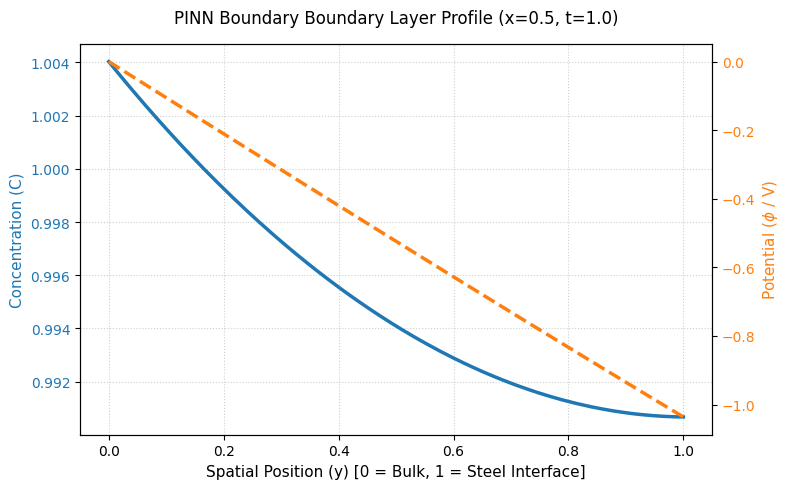

In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def visualize_production_profiles(model, data_tensors, device="cpu", x_val=0.5, t_val=1.0):
    """Plots the concentration and potential profiles from y=0 (Bulk) to y=1 (Steel)."""
    model.eval()
    x_soil, x_fluid, x_meta = [t.to(device) for t in data_tensors]
    
    # Isolate a single evaluation profile (Profile 0)
    soil_single = x_soil[0:1]
    fluid_single = x_fluid[0:1]
    meta_single = x_meta[0:1]
    
    # Build a clean y-directional spatial grid
    resolution = 200
    y_grid = torch.linspace(0.0, 1.0, resolution, device=device).view(-1, 1)
    x_grid = torch.full_like(y_grid, x_val)
    t_grid = torch.full_like(y_grid, t_val)
    
    coords = torch.cat([x_grid, y_grid, t_grid], dim=1)
    
    # Broadcast the condition tensors across the spatial grid resolution
    soil_expanded = soil_single.repeat(resolution, 1)
    fluid_expanded = fluid_single.repeat(resolution, 1)
    meta_expanded = meta_single.repeat(resolution, 1)
    
    # Inference pass
    with torch.no_grad():
        u_pred = model((soil_expanded, fluid_expanded, meta_expanded, coords))
        C_pred = u_pred[:, 0].cpu().numpy()
        phi_pred = u_pred[:, 1].cpu().numpy()
        y_axis = y_grid.cpu().numpy()
        
    # Dual-axis visualization layout
    fig, ax1 = plt.subplots(figsize=(8, 5), dpi=100)
    
    # Axis 1: Concentration
    color_c = 'tab:blue'
    ax1.set_xlabel('Spatial Position (y) [0 = Bulk, 1 = Steel Interface]', fontsize=11)
    ax1.set_ylabel('Concentration (C)', color=color_c, fontsize=11)
    ax1.plot(y_axis, C_pred, color=color_c, linewidth=2.5, label='Concentration ($C$)')
    ax1.tick_params(axis='y', labelcolor=color_c)
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # Axis 2: Potential Field
    ax2 = ax1.twinx()
    color_phi = 'tab:orange'
    ax2.set_ylabel('Potential ($\phi$ / V)', color=color_phi, fontsize=11)
    ax2.plot(y_axis, phi_pred, color=color_phi, linewidth=2.5, linestyle='--', label='Potential ($\phi$)')
    ax2.tick_params(axis='y', labelcolor=color_phi)
    
    plt.title(f'PINN Boundary Boundary Layer Profile (x={x_val}, t={t_val})', fontsize=12, pad=15)
    fig.tight_layout()
    plt.show()

# Run this cell immediately after the manual math audit completes:
visualize_production_profiles(trained_physics_model, (soil_tensor, fluid_tensor, meta_tensor), execution_device)

In [26]:
import torch
import numpy as np

def diagnostic_boundary_scan(model, data_tensors, device="cpu"):
    """High-resolution scan of the boundary layer as proposed by Claude."""
    model.eval()
    x_soil, x_fluid, x_meta = [t.to(device) for t in data_tensors]
    
    # Isolate first profile
    soil_single = x_soil[0:1]
    fluid_single = x_fluid[0:1]
    meta_single = x_meta[0:1]
    
    # Probe depths approaching the steel boundary at t=1.0, x=0.5
    y_probes = [0.5, 0.8, 0.9, 0.95, 0.99, 1.0]
    
    print("--- HIGH-RES BOUNDARY LAYER SCAN ---")
    print(f"{'y-coord':<10} | {'C_raw':<15} | {'dC/dy':<15}")
    print("-" * 45)
    
    for y_val in y_probes:
        coord = torch.tensor([[0.5, y_val, 1.0]], dtype=torch.float32, requires_grad=True, device=device)
        
        u_pred = model((soil_single, fluid_single, meta_single, coord))
        C_raw = u_pred[0, 0]
        
        # Calculate spatial gradient
        dC_dy = dde.grad.jacobian(u_pred, coord, i=0, j=1)
        
        print(f"{y_val:<10.3f} | {C_raw.item():<15.8e} | {dC_dy.item():<15.8e}")
        
    print("-" * 45)

# Execute the scan
diagnostic_boundary_scan(trained_physics_model, (soil_tensor, fluid_tensor, meta_tensor), execution_device)

--- HIGH-RES BOUNDARY LAYER SCAN ---
y-coord    | C_raw           | dC/dy          
---------------------------------------------
0.500      | 9.94093060e-01  | -1.33184344e-02
0.800      | 9.91257191e-01  | -5.55950403e-03
0.900      | 9.90833223e-01  | -2.91402638e-03
0.950      | 9.90720451e-01  | -1.57551467e-03
0.990      | 9.90679264e-01  | -4.96946275e-04
1.000      | 9.90675867e-01  | -2.26244330e-04
---------------------------------------------


In [27]:
def evaluate_pinn_accuracy(model, test_inputs, test_ground_truth, device="cpu"):
    """
    test_inputs: tuple of (soil, fluid, meta, raw_meta) for the test set
    test_ground_truth: tensor of shape [N, 2] (Concentration, Potential)
    """
    model.eval()
    with torch.no_grad():
        # Predict
        u_pred = model(test_inputs)
        
        # Calculate L2 Norms
        error_norm = torch.norm(u_pred - test_ground_truth, p=2)
        ref_norm = torch.norm(test_ground_truth, p=2)
        
        relative_l2_error = error_norm / ref_norm
        accuracy = 1.0 - relative_l2_error.item()
        
    return accuracy, relative_l2_error.item()

# Usage
acc, err = evaluate_pinn_accuracy(trained_physics_model, test_set_inputs, ground_truth)
print(f"Model Accuracy: {acc*100:.2f}% | Relative L2 Error: {err:.4f}")

NameError: name 'test_set_inputs' is not defined

In [ ]:
assert torch.save(model.state_dict(), "model.pt")

In [20]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()